In [2]:
from scgpt.tokenizer.gene_tokenizer import GeneVocab
from pathlib import Path
import scanpy as sc
import pandas as pd
import json
import numpy as np

/local/fkriegel/miniconda3/envs/scgpt_env/lib/python3.10/site-packages/scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/local/fkriegel/miniconda3/envs/scgpt_env/lib/python3.10/site-packages/scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")


In [102]:
pretrained_model_dir = Path("/local/scFM/scGPT/pretrained/scGPT_human")
path_adata = "/local/fkriegel/Moma_PD_scSAE/dat/nido_annotated.h5ad"

In [103]:
vocab_path = pretrained_model_dir / "vocab.json"
vocab = GeneVocab.from_file(vocab_path)
adata = sc.read_h5ad(path_adata)

In [104]:
dict_vocab = vocab.vocab
scgpt_vocab_genes = list(dict_vocab.keys())

In [105]:
not_in_vocab = [gene for gene in adata.var.index if gene not in scgpt_vocab_genes]

In [106]:
print(f"number of total genes in dataset:\t{len(adata.var)}")
print(f"number of genes missing from vocab:\t{len(not_in_vocab)}")

number of total genes in dataset:	36620
number of genes missing from vocab:	11814


Although there are a lot of genes missing, we will only input the hvgs into scGPT. So lets see how many of the hvgs are missing

In [107]:
mask_not_in_vocab = adata.var.index.isin(not_in_vocab)

In [108]:
adata.var

,gene_ids,feature_types,genome,canonical_feature_id,canonical_feature_id_source,mt,rb,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,highly_variable_rank,means,variances,variances_norm,highly_variable_nbatches
MIR1302-2HG,ENSG00000243485,Gene Expression,NA,ENSG00000243485.6,ensembl_archive,False,False,42,0.000115,99.988498,42,False,NaN,0.000115,0.000115,0.517190,0
FAM138A,ENSG00000237613,Gene Expression,NA,ENSG00000237613.3,ensembl_archive,False,False,0,0.000000,100.000000,0,False,NaN,0.000000,0.000000,0.000000,0
OR4F5,ENSG00000186092,Gene Expression,NA,ENSG00000186092.7,ensembl_archive,False,False,8,0.000022,99.997809,8,False,NaN,0.000022,0.000022,0.129787,0
AL627309.1,ENSG00000238009,Gene Expression,NA,ENSG00000238009.7,ensembl_archive,False,False,6979,0.020397,98.088746,7448,False,NaN,0.020397,0.022824,0.883224,0
AL627309.3,ENSG00000239945,Gene Expression,NA,ENSG00000239945.1,ensembl_archive,False,False,63,0.000173,99.982747,63,False,NaN,0.000173,0.000173,0.598749,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AC141272.1,ENSG00000277836,Gene Expression,NA,ENSG00000277836.1,ensembl_archive,False,False,0,0.000000,100.000000,0,False,NaN,0.000000,0.000000,0.000000,0
AC023491.2,ENSG00000278633,Gene Expression,NA,ENSG00000278633.1,ensembl_archive,False,False,38,0.000104,99.989593,38,False,NaN,0.000104,0.000104,0.495683,0
AC007325.1,ENSG00000276017,Gene Expression,NA,ENSG00000276017.1,ensembl_archive,False,False,9,0.000025,99.997535,9,False,NaN,0.000025,0.000025,0.173580,0
AC007325.4,ENSG00000278817,Gene Expression,NA,ENSG00000278817.1,ensembl_archive,False,False,9057,0.025896,97.519670,9456,False,NaN,0.025896,0.027482,0.841601,0


In [5]:
#!/usr/bin/env python
"""
scgpt_vocab_rescue.py

Map dataset genes onto the scGPT gene vocabulary, rescuing what can be
rescued through stable identifiers.

Resolution routes, in precedence order:
  1. Ensembl ID -> suffixed vocab token.  scGPT disambiguates duplicated
     symbols by appending the Ensembl ID (e.g. "RGS5_ENSG00000143248").
     These are invisible to any symbol-level match and must be handled
     first.  They also reach loci with no HGNC record at all.
  2. Ensembl ID -> HGNC ID -> vocab token.
  3. Approved symbol -> HGNC ID -> vocab token.
  4. prev_symbol / alias_symbol -> HGNC ID -> vocab token.  alias matches
     are the only unsafe route; review them before trusting them.

Diagnostics, in the order worth reading:
  A. What kind of genes are missing (clone-based placeholders vs real
     annotated genes).  Non-exclusive buckets -- a gene can match several.
  B. Count mass lost per cell, broken down by cell type.  This is the
     quantity that matters when subset_hvg is off, and cell-type
     asymmetry here propagates into anything learned downstream.
  C. Optional HVG overlap, only meaningful if you actually intend to
     subset to HVGs.  scGPT's Preprocessor defaults subset_hvg=False.

Inputs:
  HGNC complete set (refreshed Tue/Fri, ~15 MB, note the doubled tsv/tsv/):
    https://storage.googleapis.com/public-download-files/hgnc/tsv/tsv/hgnc_complete_set.txt
  Withdrawn symbols (merged/split entries, for stubborn residual cases):
    https://storage.googleapis.com/public-download-files/hgnc/tsv/tsv/withdrawn.txt
"""

import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import anndata as ad
import scanpy as sc

# --------------------------------------------------------------------------
# config
# --------------------------------------------------------------------------
pretrained_model_dir = Path("/local/scFM/scGPT/pretrained/scGPT_human")
path_adata = "/local/fkriegel/Moma_PD_scSAE/dat/nido_annotated.h5ad"
vocab_path = pretrained_model_dir / "vocab.json"

VOCAB_JSON = vocab_path
HGNC_TSV = "/local/fkriegel/Moma_PD_scSAE/dat/hgnc_complete_set.txt"
 
SYMBOL_COL = None      # adata.var column holding gene symbols; None -> var_names
ENSG_COL = "gene_ids"        # adata.var column holding Ensembl IDs, e.g. "gene_ids". Strongly recommended.
N_HVG = 3000           # the HVG budget you actually feed scGPT
OUT = Path("../res/scgpt_vocab_map.csv")

COUNTS_LAYER = "counts"    # raw integer counts
CELLTYPE_COL = "cell_type" # obs column for the loss-asymmetry breakdown
BATCH_COL = "sample_id"

RUN_HVG_DIAGNOSTIC = False # only if you plan to subset_hvg

OUT = Path("scgpt_vocab_map.csv")
SPECIAL_TOKENS = {"<pad>", "<cls>", "<eoc>", "<mask>", "<unk>", "<eos>", "<bos>"}

# --------------------------------------------------------------------------
# load
# --------------------------------------------------------------------------
adata = sc.read_h5ad(path_adata)

sym = pd.Index(
    adata.var_names.astype(str) if SYMBOL_COL is None
    else adata.var[SYMBOL_COL].astype(str)
)
if ENSG_COL is not None and ENSG_COL in adata.var:
    ensg = (
        adata.var[ENSG_COL].astype(str)
        .str.replace(r"\.\d+$", "", regex=True)   # strip ENSG version suffix
        .str.upper().values
    )
else:
    print("WARNING: no Ensembl IDs -- routes 1 and 2 disabled, rescue will be "
          "symbol-only and far less reliable")
    ensg = np.array([None] * adata.n_vars, dtype=object)

with open(VOCAB_JSON) as fh:
    vocab_tokens = set(json.load(fh).keys()) - SPECIAL_TOKENS

# scGPT's suffixed tokens: "SYMBOL_ENSG########"
SUFFIXED = re.compile(r"^(.+)_(ENSG\d+)$")
ensg2token = {}
for t in vocab_tokens:
    mt = SUFFIXED.match(t)
    if mt:
        ensg2token[mt.group(2).upper()] = t

in_vocab = np.array([s in vocab_tokens for s in sym])
print(f"dataset genes        : {len(sym)}")
print(f"vocab tokens         : {len(vocab_tokens)} "
      f"({len(ensg2token)} ENSG-suffixed)")
print(f"direct symbol hits   : {in_vocab.sum()}")
print(f"missing              : {(~in_vocab).sum()}")

# --------------------------------------------------------------------------
# A -- triage the missing set (non-exclusive buckets)
# --------------------------------------------------------------------------
# Clone-based placeholder names are archive accession + version, e.g.
# AC004556.1, Z97192.2, U52111.1, AF279873.3.  Requiring the ".N" version
# suffix is what keeps real genes (AP2M1, U2AF1, KIF5B) out of the bucket.
PATTERNS = {
    "clone/accession placeholder (AC004556.1)": r"^[A-Z]{1,2}\d{5,6}\.\d+$",
    "LINC#####":                                r"^LINC\d+$",
    "antisense/divergent (-AS/-DT/-IT/-OT)":    r"-(AS\d*|DT|IT\d*|OT\d*)$",
    "small RNA (MIR/SNOR/SCARNA/RNU/RNVU)":     r"^(MIR|SNOR|SCARNA|RNU|RNVU|RNA5|RNY|VTRNA)",
    "pseudogene-style (-PS#/P#)":               r"(-PS\d*$|(?<=[A-Z])P\d+$)",
    "bare Ensembl ID":                          r"^ENSG\d+",
    "MT- / HLA- (format mismatch, not renamed)": r"^(MT|HLA)-",
    "make_unique artefact (-1, -2)":            r"-\d+$",
}
missing = pd.Series(sym[~in_vocab])
matched_any = pd.Series(False, index=missing.index)
print("\nA. missing-gene triage (buckets overlap):")
for label, pat in PATTERNS.items():
    hit = missing.str.match(pat, case=False)
    matched_any |= hit
    print(f"  {int(hit.sum()):>6}  {label}")
print(f"  {int((~matched_any).sum()):>6}  matched no pattern <- the only "
      f"plausibly-renameable pool")

# --------------------------------------------------------------------------
# B -- HGNC-anchored rescue
# --------------------------------------------------------------------------
hgnc = pd.read_csv(HGNC_TSV, sep="\t", dtype=str, low_memory=False)
hgnc = hgnc[hgnc["status"] == "Approved"]
approved = dict(zip(hgnc["symbol"], hgnc["hgnc_id"]))


def _long(col, key_type, upper=False):
    d = hgnc[["hgnc_id", col]].dropna(subset=[col]).copy()
    d[col] = d[col].str.split("|")
    d = d.explode(col)
    d[col] = d[col].str.strip()
    if upper:
        d[col] = d[col].str.replace(r"\.\d+$", "", regex=True).str.upper()
    d = d.rename(columns={col: "key"})
    d["key_type"] = key_type
    return d[["key", "hgnc_id", "key_type"]]


keymap = pd.concat([
    _long("ensembl_gene_id", "ensg", upper=True),
    _long("symbol", "approved"),
    _long("prev_symbol", "prev"),
    _long("alias_symbol", "alias"),
], ignore_index=True).drop_duplicates()

# Guard 1: never resolve through a prev/alias string that is the APPROVED
# symbol of a different gene -- the classic silent-reassignment path.
hijack = (
    keymap["key_type"].isin(["prev", "alias"])
    & keymap["key"].isin(approved)
    & (keymap["key"].map(approved) != keymap["hgnc_id"])
)
print(f"\ndropped {int(hijack.sum())} prev/alias keys colliding with another "
      f"gene's approved symbol")
keymap = keymap[~hijack]

# Guard 2: a key must resolve to exactly one HGNC ID.
keymap = keymap[keymap["key"].map(keymap.groupby("key")["hgnc_id"].nunique()) == 1]

PRECEDENCE = {"ensg": 0, "approved": 1, "prev": 2, "alias": 3}
keymap["rank"] = keymap["key_type"].map(PRECEDENCE)
keymap = keymap.sort_values("rank").drop_duplicates("key", keep="first")
key2id = dict(zip(keymap["key"], keymap["hgnc_id"]))
key2type = dict(zip(keymap["key"], keymap["key_type"]))


def resolve(symbol, ensembl=None):
    """Return (hgnc_id, direct_token, evidence). direct_token bypasses HGNC."""
    if ensembl and isinstance(ensembl, str):
        if ensembl in ensg2token:
            return None, ensg2token[ensembl], "ensg_suffixed"
        if ensembl in key2id:
            return key2id[ensembl], None, "ensg"
    if symbol in key2id:
        return key2id[symbol], None, key2type[symbol]
    return None, None, None


# vocab side: plain tokens resolve through HGNC; suffixed ones are handled
# by ensg2token above and deliberately skipped here.
vocab_ids = {}
for tok in vocab_tokens:
    if SUFFIXED.match(tok):
        continue
    hid, _, _ = resolve(tok)
    if hid is not None:
        vocab_ids.setdefault(hid, []).append(tok)

claimed = set(sym[in_vocab])   # tokens already taken by a direct hit

rows = []
for i, s in enumerate(sym):
    e = ensg[i]
    if in_vocab[i]:
        rows.append((s, e, None, s, "direct", "kept"))
        continue
    hid, tok, ev = resolve(s, e)
    if tok is not None:
        cands = [tok] if tok not in claimed else []
    else:
        cands = [t for t in vocab_ids.get(hid, []) if t not in claimed] if hid else []
    if len(cands) == 1:
        rows.append((s, e, hid, cands[0], ev, "rescued"))
    elif len(cands) > 1:
        rows.append((s, e, hid, "|".join(sorted(cands)), ev, "ambiguous_multi_token"))
    else:
        rows.append((s, e, hid, None, ev, "unresolved"))

m = pd.DataFrame(rows, columns=[
    "gene", "ensembl_gene_id", "hgnc_id", "vocab_token", "evidence", "status",
])
m["in_vocab"] = in_vocab

# Guard 3: two dataset rows rescued onto the same token
resc = m.index[m["status"] == "rescued"]
dup = m.loc[resc, "vocab_token"].duplicated(keep=False).to_numpy()
m.loc[resc[dup], "status"] = "ambiguous_collision"

print("\nB. rescue outcome:")
print(m["status"].value_counts().to_string())
print("\nrescued by evidence route:")
print(m.loc[m.status == "rescued", "evidence"].value_counts().to_string())
print("\nreview these manually before applying:")
for st in ["ambiguous_multi_token", "ambiguous_collision"]:
    sub = m[m.status == st]
    if len(sub):
        print(f"  {st}: {sub['gene'].tolist()}")
alias_resc = m[(m.status == "rescued") & (m.evidence == "alias")]
if len(alias_resc):
    print(f"  alias-only rescues (unsafe route): {alias_resc['gene'].tolist()}")

m.to_csv(OUT, index=False)
print(f"\nwrote {OUT}")

# --------------------------------------------------------------------------
# C -- count mass lost, by cell type.  The decision-relevant diagnostic.
# --------------------------------------------------------------------------
keep_mask = m["status"].isin(["kept", "rescued"]).to_numpy()
C = adata.layers[COUNTS_LAYER] if COUNTS_LAYER in adata.layers else adata.X

if sp.issparse(C):
    nz = C[:100].data if C.nnz else np.array([1.0])
else:
    nz = np.asarray(C[:100]).ravel()
if not np.allclose(nz, np.round(nz)):
    print("\nWARNING: counts layer is non-integer. If this matrix has been "
          "log-transformed, every variance-based ranking below (and any "
          "seurat_v3 HVG call) is fitted on the wrong scale and will fail "
          "silently rather than error.")

tot = np.asarray(C.sum(1)).ravel()
lost = np.asarray(C[:, ~keep_mask].sum(1)).ravel()
adata.obs["frac_counts_lost"] = np.where(tot > 0, lost / np.maximum(tot, 1), np.nan)

print(f"\nC. count mass lost to vocab filtering: "
      f"median {np.nanmedian(adata.obs['frac_counts_lost']):.3%}")
if CELLTYPE_COL in adata.obs:
    tab = (adata.obs.groupby(CELLTYPE_COL, observed=True)["frac_counts_lost"]
           .agg(["mean", "std", "count"]).sort_values("mean"))
    print(tab.to_string(float_format=lambda x: f"{x:.4f}"))
    spread = tab["mean"].max() - tab["mean"].min()
    print(f"\nspread across cell types: {spread:.2%} "
          f"-- a uniform loss is ignorable; a multi-point spread means the "
          f"vocab filter is a cell-type-dependent input perturbation")

# --------------------------------------------------------------------------
# D -- optional HVG overlap (only if you intend to subset_hvg)
# --------------------------------------------------------------------------
if RUN_HVG_DIAGNOSTIC:
    hv = ad.AnnData(X=C.copy(), obs=adata.obs.copy(),
                    var=pd.DataFrame(index=adata.var_names))
    sc.pp.highly_variable_genes(
        hv, n_top_genes=N_HVG, flavor="seurat_v3",
        batch_key=BATCH_COL if BATCH_COL in hv.obs else None,
    )
    is_hvg = hv.var["highly_variable"].to_numpy()
    m["is_hvg"] = is_hvg
    del hv

    lost_hvg = m["is_hvg"] & ~keep_mask
    clone = m["gene"].str.match(PATTERNS["clone/accession placeholder (AC004556.1)"])
    print(f"\nD. top-{N_HVG} HVGs not in vocab after rescue: {int(lost_hvg.sum())}")
    print(f"   of which clone/accession placeholders: {int((lost_hvg & clone).sum())}")
    print(f"   annotated genes genuinely lost: "
          f"{m.loc[lost_hvg & ~clone, 'gene'].tolist()}")
    m.to_csv(OUT, index=False)

# --------------------------------------------------------------------------
# E -- apply
# --------------------------------------------------------------------------
def apply_map(adata, m, symbol_col=None):
    """Subset to mappable genes, rename to vocab tokens, sum collapsed rows."""
    new = m["vocab_token"].where(m["status"].isin(["kept", "rescued"]))
    keep = new.notna().to_numpy()
    out = adata[:, keep].copy()
    out.var["orig_gene"] = (
        out.var_names.astype(str) if symbol_col is None
        else out.var[symbol_col].astype(str)
    ).values
    out.var_names = pd.Index(new[keep].astype(str).values)
    n_dup = int(out.var_names.duplicated().sum())
    if n_dup:
        print(f"collapsing {n_dup} duplicate token(s) by summing counts")
        out = _sum_dups(out)
    return out


def _sum_dups(a):
    """Sum rows sharing a var_name. Reorders vars alphabetically."""
    groups = pd.Categorical(a.var_names)
    ind = sp.csr_matrix(
        (np.ones(a.n_vars), (np.arange(a.n_vars), groups.codes)),
        shape=(a.n_vars, len(groups.categories)),
    )
    def mm(M):
        return M @ ind if sp.issparse(M) else np.asarray(M @ ind.toarray())
    return ad.AnnData(
        X=mm(a.X),
        obs=a.obs.copy(),
        var=pd.DataFrame(index=pd.Index(groups.categories, name=None)),
        layers={k: mm(v) for k, v in a.layers.items()},
    )



# drop the two flagged clone placeholders -> 492
m.loc[m.status.isin(["ambiguous_multi_token", "ambiguous_collision"]), "status"] = "unresolved"
m.loc[(m.status == "rescued") & (m.evidence == "alias"), "status"] = "unresolved"
m.loc[m.status == "unresolved", "vocab_token"] = None
m.to_csv(OUT, index=False)
print(m.status.value_counts().to_string())   # expect kept 24806, rescued 492
adata_v = apply_map(adata, m, SYMBOL_COL)
print(adata_v.shape)                          # expect (n_cells, 25298)
assert adata_v.var_names.isin(vocab_tokens).all()
adata_v.write_h5ad("/local/fkriegel/Moma_PD_scSAE/dat/nido_annotated.h5ad")

dataset genes        : 25298
vocab tokens         : 60694 (1363 ENSG-suffixed)
direct symbol hits   : 25298
missing              : 0

A. missing-gene triage (buckets overlap):
       0  clone/accession placeholder (AC004556.1)
       0  LINC#####
       0  antisense/divergent (-AS/-DT/-IT/-OT)
       0  small RNA (MIR/SNOR/SCARNA/RNU/RNVU)
       0  pseudogene-style (-PS#/P#)
       0  bare Ensembl ID
       0  MT- / HLA- (format mismatch, not renamed)
       0  make_unique artefact (-1, -2)
       0  matched no pattern <- the only plausibly-renameable pool

dropped 739 prev/alias keys colliding with another gene's approved symbol

B. rescue outcome:
status
kept    25298

rescued by evidence route:
Series([], )

review these manually before applying:

wrote scgpt_vocab_map.csv

C. count mass lost to vocab filtering: median 0.000%
                   mean    std   count
cell_type                             
OPC              0.0000 0.0000   14055
astrocytes       0.0000 0.0000   24912
en

In [112]:
#!/usr/bin/env python
"""
nido_hvg_artefact_check.py

Why are ~24% of the top-3000 HVGs unannotated clone-based loci?

Three competing explanations, each with a distinct signature:

  (1) Ambient / sample-specific contamination
      -> counts concentrated in one or a few samples
      -> flat across cell types (no specificity)
  (2) Detection noise at the low end of the VST mean-variance fit
      -> very low mean expression and detection rate
      -> HVG ranks bunched near the 3000 cutoff
  (3) Real cell-type-specific novel transcripts
      -> spread across samples
      -> concentrated in one cell type
      -> comparable detection to retained HVGs

The script compares three gene groups on the same metrics:
  lost_hvg    HVG, not mappable to the scGPT vocab
  kept_hvg    HVG, mappable
  non_hvg     everything else
If lost_hvg looks like kept_hvg, the vocab filter is removing real signal.
If it looks like (1) or (2), the HVG ranking itself needs fixing -- which
affects the scVI integration and Leiden clustering too, not just scGPT.

Requires the `m` table from scgpt_vocab_rescue.py (scgpt_vocab_map.csv).
"""

import numpy as np
import pandas as pd
import scipy.sparse as sp
import anndata as ad
import scanpy as sc

# --------------------------------------------------------------------------
H5AD = "adata.h5ad"
MAP_CSV = "scgpt_vocab_map.csv"
COUNTS_LAYER = "counts"
SAMPLE_COL = "sample_id"
CELLTYPE_COL = "cell_type"
N_HVG = 3000
OUT_CSV = "../res/hvg_artefact_metrics.csv"

m = pd.read_csv(MAP_CSV)
assert len(m) == adata.n_vars, "map table and adata are out of sync"

C = adata.layers[COUNTS_LAYER] if COUNTS_LAYER in adata.layers else adata.X
C = sp.csr_matrix(C) if not sp.issparse(C) else C.tocsr()
n_cells, n_genes = C.shape

# --------------------------------------------------------------------------
# HVG call (same settings as the pipeline) -- keep the rank, not just the flag
# --------------------------------------------------------------------------
hv = ad.AnnData(X=C.copy(), obs=adata.obs.copy(),
                var=pd.DataFrame(index=adata.var_names))
sc.pp.highly_variable_genes(hv, n_top_genes=N_HVG, flavor="seurat_v3",
                            batch_key=SAMPLE_COL if SAMPLE_COL in hv.obs else None)
m["is_hvg"] = hv.var["highly_variable"].to_numpy()
m["hvg_rank"] = hv.var["highly_variable_rank"].to_numpy()
m["var_norm"] = hv.var["variances_norm"].to_numpy()
del hv

mappable = m["status"].isin(["kept", "rescued"]).to_numpy()
group = np.where(m["is_hvg"] & ~mappable, "lost_hvg",
         np.where(m["is_hvg"] & mappable, "kept_hvg", "non_hvg"))
m["group"] = group
print("group sizes:")
print(m["group"].value_counts().to_string(), "\n")

# --------------------------------------------------------------------------
# gene-level abundance and detection
# --------------------------------------------------------------------------
tot_per_cell = np.asarray(C.sum(1)).ravel()
gene_counts = np.asarray(C.sum(0)).ravel()
m["total_counts"] = gene_counts
m["mean_cpm"] = 1e6 * gene_counts / gene_counts.sum()
m["detect_rate"] = np.asarray((C > 0).sum(0)).ravel() / n_cells

# mean of log1p-CP10K, i.e. what the variance ranking effectively sees
Cn = (sp.diags(1e4 / np.maximum(tot_per_cell, 1)) @ C).tocsr()
Cn.data = np.log1p(Cn.data)
m["mean_lognorm"] = np.asarray(Cn.mean(0)).ravel()
del Cn

# --------------------------------------------------------------------------
# pseudobulk concentration: samples (artefact axis) and cell types (biology axis)
# --------------------------------------------------------------------------
def pseudobulk_share(labels):
    """Per-gene share of counts in its top group, plus n groups detected."""
    cat = pd.Categorical(labels)
    G = sp.csr_matrix(
        (np.ones(len(cat)), (np.arange(len(cat)), cat.codes)),
        shape=(len(cat), len(cat.categories)),
    )
    # groups x genes, CPM-normalised within group to remove depth differences
    pb = np.asarray((G.T @ C).todense(), dtype=float)
    depth = pb.sum(1, keepdims=True)
    cpm = 1e6 * pb / np.maximum(depth, 1)
    tot = cpm.sum(0)
    share = np.divide(cpm.max(0), tot, out=np.zeros_like(tot), where=tot > 0)
    n_det = (pb > 0).sum(0)
    top = np.array(cat.categories)[cpm.argmax(0)]
    return share, n_det, top, len(cat.categories)


if SAMPLE_COL in adata.obs:
    s_share, s_ndet, s_top, n_samp = pseudobulk_share(adata.obs[SAMPLE_COL])
    m["top_sample_share"] = s_share
    m["n_samples_detected"] = s_ndet
    m["top_sample"] = s_top
    print(f"{n_samp} samples; a share of ~{1/n_samp:.3f} means evenly spread")

if CELLTYPE_COL in adata.obs:
    c_share, c_ndet, c_top, n_ct = pseudobulk_share(adata.obs[CELLTYPE_COL])
    m["top_celltype_share"] = c_share
    m["top_celltype"] = c_top
    print(f"{n_ct} cell types; a share of ~{1/n_ct:.3f} means flat "
          f"(ambient-like), high means cell-type specific\n")

# --------------------------------------------------------------------------
# group comparison
# --------------------------------------------------------------------------
METRICS = ["mean_cpm", "detect_rate", "mean_lognorm", "var_norm", "hvg_rank",
           "top_sample_share", "n_samples_detected", "top_celltype_share"]
METRICS = [c for c in METRICS if c in m]

print("median per group:")
print(m.groupby("group")[METRICS].median().to_string(
    float_format=lambda x: f"{x:.4g}"))

print("\nlost_hvg signature counts:")
lost = m[m.group == "lost_hvg"]
kept = m[m.group == "kept_hvg"]
n = len(lost)
if "top_sample_share" in m:
    thr = 5 / n_samp   # 5x an even split
    print(f"  single/few-sample dominated (top sample >{thr:.2f} of counts): "
          f"{(lost.top_sample_share > thr).sum()}/{n} "
          f"vs {(kept.top_sample_share > thr).mean():.1%} of kept_hvg")
    print(f"  detected in <half the samples: "
          f"{(lost.n_samples_detected < n_samp/2).sum()}/{n} "
          f"vs {(kept.n_samples_detected < n_samp/2).mean():.1%} of kept_hvg")
print(f"  detected in <1% of nuclei: {(lost.detect_rate < 0.01).sum()}/{n} "
      f"vs {(kept.detect_rate < 0.01).mean():.1%} of kept_hvg")
print(f"  HVG rank in the bottom third (>{int(N_HVG*2/3)}): "
      f"{(lost.hvg_rank > N_HVG*2/3).sum()}/{n} "
      f"vs {(kept.hvg_rank > N_HVG*2/3).mean():.1%} of kept_hvg")
if "top_celltype_share" in m:
    print(f"  cell-type specific (top type >0.5 of counts): "
          f"{(lost.top_celltype_share > 0.5).sum()}/{n} "
          f"vs {(kept.top_celltype_share > 0.5).mean():.1%} of kept_hvg")
    print(f"  flat across cell types (top type <{1.5/n_ct:.2f}): "
          f"{(lost.top_celltype_share < 1.5/n_ct).sum()}/{n} "
          f"vs {(kept.top_celltype_share < 1.5/n_ct).mean():.1%} of kept_hvg")

if "top_sample" in m:
    print("\nwhich samples drive the lost HVGs (top 10):")
    print(lost["top_sample"].value_counts().head(10).to_string())
    print(f"expected per sample under an even spread: {n/n_samp:.1f}")

if "top_celltype" in m:
    print("\nwhich cell types the lost HVGs peak in:")
    print(lost["top_celltype"].value_counts().to_string())

# how much count mass do the lost HVGs actually carry?
print(f"\nlost HVGs carry {1e-4 * lost.mean_cpm.sum():.3f}% of all counts "
      f"({lost.total_counts.sum():.3g} counts); kept HVGs carry "
      f"{1e-4 * kept.mean_cpm.sum():.2f}%")

m.to_csv(OUT_CSV, index=False)
print(f"\nwrote {OUT_CSV}")

# --------------------------------------------------------------------------
# how to read it
# --------------------------------------------------------------------------
print("""
Reading the result
  Ambient/sample artefact   high top_sample_share, low n_samples_detected,
                            top_celltype_share near flat, and the top_sample
                            counts piling onto a few sample IDs.
                            -> revisit CellBender; consider excluding these
                               genes from HVG selection everywhere, not just
                               for scGPT.
  Detection noise           mean_cpm and detect_rate an order of magnitude
                            below kept_hvg, hvg_rank bunched near the cutoff.
                            -> add a min-cells / min-counts prefilter before
                               highly_variable_genes; the ranking is fitting
                               the poorly-constrained low end of the VST curve.
  Real novel transcripts    metrics comparable to kept_hvg, spread across
                            samples, concentrated in one cell type.
                            -> the vocab filter is discarding real signal;
                               worth noting as a limitation of using scGPT
                               on this reference build.
""")

group sizes:
group
non_hvg     33620
kept_hvg     2273
lost_hvg      727 

46 samples; a share of ~0.022 means evenly spread
7 cell types; a share of ~0.143 means flat (ambient-like), high means cell-type specific

median per group:
          mean_cpm  detect_rate  mean_lognorm  var_norm  hvg_rank  top_sample_share  n_samples_detected  top_celltype_share
group                                                                                                                      
kept_hvg     9.367      0.06042       0.05295     1.679      1244           0.06415                  46              0.5539
lost_hvg      2.59      0.01786       0.01433     1.687      1246           0.07686                  46              0.5375
non_hvg       1.09      0.01186      0.007313     0.891      2385           0.05614                  46              0.3486

lost_hvg signature counts:
  single/few-sample dominated (top sample >0.11 of counts): 177/727 vs 22.6% of kept_hvg
  detected in <half the sample

## Bottom line

- we will not filter genes based on `--filter_gene_by_fraction`
- from our 3000 hvgs ~700 (25%) are not in the scGPT vocab
- the 25% missing are mostly long non-coding RNAs. This is a problem because this is an unusal high percentage for hvg selection
- in the last analysis, Claude checked whether the the hvg selection is likely correct (See Chat: *Rescuing missing genes from scGPT vocabulary*)
- once this is done, I can start finetuning
- first thing to explore after finetuning: what are the high shift genes?

## Renaming

With Ilia I discussed that we will first filter the adata abject for genes present in scGPTs vocab and than compute the hvgs.

In [18]:
#!/usr/bin/env python
"""
scgpt_vocab_rescue.py

Map dataset genes onto the scGPT gene vocabulary, rescue what stable
identifiers allow, then *subset to the vocab* and compute HVGs on the
filtered object.

Order matters here: HVG selection now runs on the vocab-restricted matrix,
so the N_HVG budget is spent only on genes scGPT can actually represent.
Previously the top-3000 were drawn from the full ~36k var space and any
HVG outside the vocab was silently discarded downstream.

Resolution routes, in precedence order:
  1. Ensembl ID -> suffixed vocab token.  scGPT disambiguates duplicated
     symbols by appending the Ensembl ID (e.g. "RGS5_ENSG00000143248").
     These are invisible to any symbol-level match and must be handled
     first.  They also reach loci with no HGNC record at all.
  2. Ensembl ID -> HGNC ID -> vocab token.
  3. Approved symbol -> HGNC ID -> vocab token.
  4. prev_symbol / alias_symbol -> HGNC ID -> vocab token.  alias matches
     are the only unsafe route; off by default (ACCEPT_ALIAS).

Sections:
  A. Triage of the missing set (clone placeholders vs real annotated genes).
     Non-exclusive buckets -- a gene can match several.
  B. HGNC-anchored rescue, with three collision guards.
  C. Count mass lost per cell, by cell type.  Run on the *pre-filter*
     matrix, because that is the only place the lost mass still exists.
     Cell-type asymmetry here propagates into anything learned downstream.
  D. Apply: subset + rename -> adata_v, containing only vocab tokens.
  E. HVG on adata_v (flag only, no subsetting -- scGPT's Preprocessor
     defaults subset_hvg=False; flip SUBSET_HVG if you want it hard-cut).

Inputs:
  HGNC complete set (refreshed Tue/Fri, ~15 MB, note the doubled tsv/tsv/):
    https://storage.googleapis.com/public-download-files/hgnc/tsv/tsv/hgnc_complete_set.txt
"""

import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import anndata as ad
import scanpy as sc

# --------------------------------------------------------------------------
# config
# --------------------------------------------------------------------------

pretrained_model_dir = Path("/local/scFM/scGPT/pretrained/scGPT_human")
path_adata = "/local/fkriegel/Moma_PD_scSAE/dat/nido_annotated.h5ad"
vocab_path = pretrained_model_dir / "vocab.json"

VOCAB_JSON = vocab_path          # notebook variable
HGNC_TSV = "/local/fkriegel/Moma_PD_scSAE/dat/hgnc_complete_set.txt"

SYMBOL_COL = None                # var column with symbols; None -> var_names
ENSG_COL = "gene_ids"            # var column with Ensembl IDs. Strongly recommended.

COUNTS_LAYER = "counts"          # raw integer counts
CELLTYPE_COL = "cell_type"
BATCH_COL = "sample_id"

# rescue policy -- these decide keep_mask, so they must be set before C
ACCEPT_ALIAS = False             # alias_symbol route is the unsafe one
ACCEPT_AMBIGUOUS = False         # multi-token / collision cases

# HVG, computed on the vocab-filtered object
COMPUTE_HVG = True
N_HVG = 3000
HVG_FLAVOR = "seurat_v3"         # needs raw counts + scikit-misc installed
SUBSET_HVG = True               # True -> adata_v is cut to N_HVG genes

MAP_OUT = Path("/local/fkriegel/Moma_PD_scSAE/res/scgpt_vocab_map.csv")
H5AD_OUT = Path("/local/fkriegel/Moma_PD_scSAE/dat/nido_annotated.h5ad")

SPECIAL_TOKENS = {"<pad>", "<cls>", "<eoc>", "<mask>", "<unk>", "<eos>", "<bos>"}

# --------------------------------------------------------------------------
# load
# --------------------------------------------------------------------------
adata = sc.read_h5ad(path_adata)
sym = pd.Index(
    adata.var_names.astype(str) if SYMBOL_COL is None
    else adata.var[SYMBOL_COL].astype(str)
)
if ENSG_COL is not None and ENSG_COL in adata.var:
    ensg = (
        adata.var[ENSG_COL].astype(str)
        .str.replace(r"\.\d+$", "", regex=True)   # strip ENSG version suffix
        .str.upper().values
    )
else:
    print("WARNING: no Ensembl IDs -- routes 1 and 2 disabled, rescue will be "
          "symbol-only and far less reliable")
    ensg = np.array([None] * adata.n_vars, dtype=object)

with open(VOCAB_JSON) as fh:
    vocab_tokens = set(json.load(fh).keys()) - SPECIAL_TOKENS

# scGPT's suffixed tokens: "SYMBOL_ENSG########"
SUFFIXED = re.compile(r"^(.+)_(ENSG\d+)$")
ensg2token = {}
for t in vocab_tokens:
    mt = SUFFIXED.match(t)
    if mt:
        ensg2token[mt.group(2).upper()] = t

in_vocab = np.array([s in vocab_tokens for s in sym])
print(f"dataset genes        : {len(sym)}")
print(f"vocab tokens         : {len(vocab_tokens)} "
      f"({len(ensg2token)} ENSG-suffixed)")
print(f"direct symbol hits   : {in_vocab.sum()}")
print(f"missing              : {(~in_vocab).sum()}")

# --------------------------------------------------------------------------
# A -- triage the missing set (non-exclusive buckets)
# --------------------------------------------------------------------------
PATTERNS = {
    "clone/accession placeholder (AC004556.1)": r"^[A-Z]{1,2}\d{5,6}\.\d+$",
    "LINC#####":                                r"^LINC\d+$",
    "antisense/divergent (-AS/-DT/-IT/-OT)":    r"-(AS\d*|DT|IT\d*|OT\d*)$",
    "small RNA (MIR/SNOR/SCARNA/RNU/RNVU)":     r"^(MIR|SNOR|SCARNA|RNU|RNVU|RNA5|RNY|VTRNA)",
    "pseudogene-style (-PS#/P#)":               r"(-PS\d*$|(?<=[A-Z])P\d+$)",
    "bare Ensembl ID":                          r"^ENSG\d+",
    "MT- / HLA- (format mismatch, not renamed)": r"^(MT|HLA)-",
    "make_unique artefact (-1, -2)":            r"-\d+$",
}
missing = pd.Series(sym[~in_vocab])
matched_any = pd.Series(False, index=missing.index)
print("\nA. missing-gene triage (buckets overlap):")
for label, pat in PATTERNS.items():
    hit = missing.str.match(pat, case=False)
    matched_any |= hit
    print(f"  {int(hit.sum()):>6}  {label}")
print(f"  {int((~matched_any).sum()):>6}  matched no pattern <- the only "
      f"plausibly-renameable pool")

# --------------------------------------------------------------------------
# B -- HGNC-anchored rescue
# --------------------------------------------------------------------------
hgnc = pd.read_csv(HGNC_TSV, sep="\t", dtype=str, low_memory=False)
hgnc = hgnc[hgnc["status"] == "Approved"]
approved = dict(zip(hgnc["symbol"], hgnc["hgnc_id"]))


def _long(col, key_type, upper=False):
    d = hgnc[["hgnc_id", col]].dropna(subset=[col]).copy()
    d[col] = d[col].str.split("|")
    d = d.explode(col)
    d[col] = d[col].str.strip()
    if upper:
        d[col] = d[col].str.replace(r"\.\d+$", "", regex=True).str.upper()
    d = d.rename(columns={col: "key"})
    d["key_type"] = key_type
    return d[["key", "hgnc_id", "key_type"]]


keymap = pd.concat([
    _long("ensembl_gene_id", "ensg", upper=True),
    _long("symbol", "approved"),
    _long("prev_symbol", "prev"),
    _long("alias_symbol", "alias"),
], ignore_index=True).drop_duplicates()

# Guard 1: never resolve through a prev/alias string that is the APPROVED
# symbol of a different gene -- the classic silent-reassignment path.
hijack = (
    keymap["key_type"].isin(["prev", "alias"])
    & keymap["key"].isin(approved)
    & (keymap["key"].map(approved) != keymap["hgnc_id"])
)
print(f"\ndropped {int(hijack.sum())} prev/alias keys colliding with another "
      f"gene's approved symbol")
keymap = keymap[~hijack]

# Guard 2: a key must resolve to exactly one HGNC ID.
keymap = keymap[keymap["key"].map(keymap.groupby("key")["hgnc_id"].nunique()) == 1]

PRECEDENCE = {"ensg": 0, "approved": 1, "prev": 2, "alias": 3}
keymap["rank"] = keymap["key_type"].map(PRECEDENCE)
keymap = keymap.sort_values("rank").drop_duplicates("key", keep="first")
key2id = dict(zip(keymap["key"], keymap["hgnc_id"]))
key2type = dict(zip(keymap["key"], keymap["key_type"]))


def resolve(symbol, ensembl=None):
    """Return (hgnc_id, direct_token, evidence). direct_token bypasses HGNC."""
    if ensembl and isinstance(ensembl, str):
        if ensembl in ensg2token:
            return None, ensg2token[ensembl], "ensg_suffixed"
        if ensembl in key2id:
            return key2id[ensembl], None, "ensg"
    if symbol in key2id:
        return key2id[symbol], None, key2type[symbol]
    return None, None, None


# vocab side: plain tokens resolve through HGNC; suffixed ones are handled
# by ensg2token above and deliberately skipped here.
vocab_ids = {}
for tok in vocab_tokens:
    if SUFFIXED.match(tok):
        continue
    hid, _, _ = resolve(tok)
    if hid is not None:
        vocab_ids.setdefault(hid, []).append(tok)

claimed = set(sym[in_vocab])   # tokens already taken by a direct hit

rows = []
for i, s in enumerate(sym):
    e = ensg[i]
    if in_vocab[i]:
        rows.append((s, e, None, s, "direct", "kept"))
        continue
    hid, tok, ev = resolve(s, e)
    if tok is not None:
        cands = [tok] if tok not in claimed else []
    else:
        cands = [t for t in vocab_ids.get(hid, []) if t not in claimed] if hid else []
    if len(cands) == 1:
        rows.append((s, e, hid, cands[0], ev, "rescued"))
    elif len(cands) > 1:
        rows.append((s, e, hid, "|".join(sorted(cands)), ev, "ambiguous_multi_token"))
    else:
        rows.append((s, e, hid, None, ev, "unresolved"))

m = pd.DataFrame(rows, columns=[
    "gene", "ensembl_gene_id", "hgnc_id", "vocab_token", "evidence", "status",
])
m["in_vocab"] = in_vocab

# Guard 3: two dataset rows rescued onto the same token
resc = m.index[m["status"] == "rescued"]
dup = m.loc[resc, "vocab_token"].duplicated(keep=False).to_numpy()
m.loc[resc[dup], "status"] = "ambiguous_collision"

print("\nB. rescue outcome (pre-policy):")
print(m["status"].value_counts().to_string())
print("\nrescued by evidence route:")
print(m.loc[m.status == "rescued", "evidence"].value_counts().to_string())
for st in ["ambiguous_multi_token", "ambiguous_collision"]:
    sub = m[m.status == st]
    if len(sub):
        print(f"  {st}: {sub['gene'].tolist()}")
alias_resc = m[(m.status == "rescued") & (m.evidence == "alias")]
if len(alias_resc):
    print(f"  alias-only rescues (unsafe route): {alias_resc['gene'].tolist()}")

# ---- apply rescue policy ------------------------------------------------
if not ACCEPT_AMBIGUOUS:
    m.loc[m.status.isin(["ambiguous_multi_token", "ambiguous_collision"]),
          "status"] = "unresolved"
if not ACCEPT_ALIAS:
    m.loc[(m.status == "rescued") & (m.evidence == "alias"), "status"] = "unresolved"
m.loc[m.status == "unresolved", "vocab_token"] = None

keep_mask = m["status"].isin(["kept", "rescued"]).to_numpy()
print("\nfinal status counts:")
print(m.status.value_counts().to_string())      # expect kept 24806, rescued 492

MAP_OUT.parent.mkdir(parents=True, exist_ok=True)
m.to_csv(MAP_OUT, index=False)
print(f"wrote {MAP_OUT}")

# --------------------------------------------------------------------------
# C -- count mass lost, by cell type.  Must run BEFORE subsetting.
# --------------------------------------------------------------------------
C = adata.layers[COUNTS_LAYER] if COUNTS_LAYER in adata.layers else adata.X

if sp.issparse(C):
    nz = C[:100].data if C.nnz else np.array([1.0])
else:
    nz = np.asarray(C[:100]).ravel()
if not np.allclose(nz, np.round(nz)):
    print("\nWARNING: counts layer is non-integer. If this matrix has been "
          "log-transformed, every variance-based ranking below (and any "
          "seurat_v3 HVG call) is fitted on the wrong scale and will fail "
          "silently rather than error.")

tot = np.asarray(C.sum(1)).ravel()
lost = np.asarray(C[:, ~keep_mask].sum(1)).ravel()
adata.obs["frac_counts_lost"] = np.where(tot > 0, lost / np.maximum(tot, 1), np.nan)

print(f"\nC. count mass lost to vocab filtering: "
      f"median {np.nanmedian(adata.obs['frac_counts_lost']):.3%}")
if CELLTYPE_COL in adata.obs:
    tab = (adata.obs.groupby(CELLTYPE_COL, observed=True)["frac_counts_lost"]
           .agg(["mean", "std", "count"]).sort_values("mean"))
    print(tab.to_string(float_format=lambda x: f"{x:.4f}"))
    spread = tab["mean"].max() - tab["mean"].min()
    print(f"\nspread across cell types: {spread:.2%} "
          f"-- a uniform loss is ignorable; a multi-point spread means the "
          f"vocab filter is a cell-type-dependent input perturbation")

del C, tot, lost

# --------------------------------------------------------------------------
# D -- apply: subset to vocab + rename to vocab tokens
# --------------------------------------------------------------------------
def _sum_dups(a):
    """Sum columns sharing a var_name. Reorders vars alphabetically.

    Only meaningful for count-scale matrices; summing log-scale values is
    not defined, so this warns if X looks non-integer and duplicates exist.
    """
    groups = pd.Categorical(a.var_names)
    cats = groups.categories
    ind = sp.csr_matrix(
        (np.ones(a.n_vars), (np.arange(a.n_vars), groups.codes)),
        shape=(a.n_vars, len(cats)),
    )

    def mm(M):
        return M @ ind if sp.issparse(M) else np.asarray(np.asarray(M) @ ind.toarray())

    var = (
        a.var.astype(str).assign(_tok=np.asarray(groups))
        .groupby("_tok", observed=True)
        .agg(lambda s: "|".join(sorted(set(s))))
        .reindex(cats)
    )
    out = ad.AnnData(
        X=mm(a.X),
        obs=a.obs.copy(),
        var=var,
        layers={k: mm(v) for k, v in a.layers.items()},
        obsm={k: v.copy() for k, v in a.obsm.items()},
        uns=dict(a.uns),
    )
    out.var_names = pd.Index(cats, name=None)
    return out


def apply_map(adata, m, symbol_col=None):
    """Subset to mappable genes, rename to vocab tokens, sum collapsed rows."""
    new = m["vocab_token"].where(m["status"].isin(["kept", "rescued"]))
    keep = new.notna().to_numpy()
    out = adata[:, keep].copy()
    out.var["orig_gene"] = (
        out.var_names.astype(str) if symbol_col is None
        else out.var[symbol_col].astype(str)
    ).values
    out.var_names = pd.Index(new[keep].astype(str).values)
    n_dup = int(out.var_names.duplicated().sum())
    if n_dup:
        print(f"collapsing {n_dup} duplicate token(s) by summing counts")
        out = _sum_dups(out)
    return out


adata_v = apply_map(adata, m, SYMBOL_COL)
assert adata_v.var_names.isin(vocab_tokens).all()
assert not adata_v.var_names.duplicated().any()
print(f"\nD. vocab-filtered object: {adata_v.shape}   "
      f"({adata.n_vars - adata_v.n_vars} genes dropped)")

# --------------------------------------------------------------------------
# E -- HVG, computed on the vocab-filtered object
# --------------------------------------------------------------------------
if COMPUTE_HVG:
    layer = COUNTS_LAYER if COUNTS_LAYER in adata_v.layers else None
    M = adata_v.layers[layer] if layer else adata_v.X
    nz = (M[:100].data if M.nnz else np.array([1.0])) if sp.issparse(M) \
        else np.asarray(M[:100]).ravel()
    is_int = np.allclose(nz, np.round(nz))
    if HVG_FLAVOR == "seurat_v3" and not is_int:
        raise ValueError(
            f"HVG_FLAVOR='seurat_v3' requires raw counts, but "
            f"{'layer ' + layer if layer else 'X'} is non-integer. Either point "
            f"COUNTS_LAYER at the true counts or switch to flavor='seurat'."
        )

    sc.pp.highly_variable_genes(
        adata_v,
        n_top_genes=N_HVG,
        flavor=HVG_FLAVOR,
        layer=layer if HVG_FLAVOR == "seurat_v3" else None,
        batch_key=BATCH_COL if BATCH_COL in adata_v.obs else None,
        subset=False,
    )
    n_hv = int(adata_v.var["highly_variable"].sum())
    print(f"E. HVGs flagged on vocab space: {n_hv} / {adata_v.n_vars}")

    if SUBSET_HVG:
        adata_v = adata_v[:, adata_v.var["highly_variable"]].copy()
        print(f"   subset to {adata_v.shape}")

# --------------------------------------------------------------------------
# write
# --------------------------------------------------------------------------
adata_v.write_h5ad(H5AD_OUT)
print(f"wrote {H5AD_OUT}  {adata_v.shape}")

dataset genes        : 25298
vocab tokens         : 60694 (1363 ENSG-suffixed)
direct symbol hits   : 25298
missing              : 0

A. missing-gene triage (buckets overlap):
       0  clone/accession placeholder (AC004556.1)
       0  LINC#####
       0  antisense/divergent (-AS/-DT/-IT/-OT)
       0  small RNA (MIR/SNOR/SCARNA/RNU/RNVU)
       0  pseudogene-style (-PS#/P#)
       0  bare Ensembl ID
       0  MT- / HLA- (format mismatch, not renamed)
       0  make_unique artefact (-1, -2)
       0  matched no pattern <- the only plausibly-renameable pool

dropped 739 prev/alias keys colliding with another gene's approved symbol

B. rescue outcome (pre-policy):
status
kept    25298

rescued by evidence route:
Series([], )

final status counts:
status
kept    25298
wrote /local/fkriegel/Moma_PD_scSAE/res/scgpt_vocab_map.csv

C. count mass lost to vocab filtering: median 0.000%
                   mean    std   count
cell_type                             
OPC              0.0000 0.0000 

In [19]:
adata_v

AnnData object with n_obs × n_vars = 312665 × 3000
    obs: 'dataset_key', 'dataset_id', 'tissue', 'donor_id', 'sample_id', 'sex', 'disease', 'organ_canonical', 'source_file', 'gen_sample_id', 'gen_cohort', 'gen_biobank_id', 'gen_bulk_rna_id', 'gen_age_death', 'gen_pmi_hours', 'gen_braak_lb', 'gen_rin', 'gen_lrrk2_variant', 'source_batch_key', 'disease_term_canonical', 'disease_ontology_term_id_canonical', 'disease_status', 'disease_category_canonical', 'disease_category_id', 'disease_term_id', 'disease_subtype_canonical', 'disease_subtype_id', 'disease_subtype_source', 'disease_comorbidity', 'genotype_panel', 'genotype_method', 'genotype_source', 'pd_variant_genes', 'pd_variant_alleles', 'pd_variant_zygosity', 'pd_variant_inheritance', 'pd_variant_count', 'genetic_etiology', 'genetic_etiology_gene', 'genetic_etiology_mode', 'hoehn_yahr_stage', 'hoehn_yahr_stage_group', 'hoehn_yahr_stage_source', 'sex_canonical', 'tissue_raw', 'tissue_original', 'tissue_canonical', 'tissue_allen_struct

In [16]:
adata_v.var["highly_variable"].sum()

3000

In [28]:
adata_v.X.count_nonzero(axis=1).max()

1459

In [30]:
adata_v.obs.disease

AAACCCACACTTCATT-1-PFCTX001_filtered    Control
AGAAATGGTTGCTCGG-1-PFCTX001_filtered    Control
TTCACGCCATCATGAC-1-PFCTX001_filtered    Control
CTCACTGCAGGCTACC-1-PFCTX001_filtered    Control
TGCAGATTCTTCGGAA-1-PFCTX001_filtered    Control
                                         ...   
TTTCATGAGCACGGAT-1-PFCTX046_filtered    Control
GCGTTTCAGGTTGGTG-1-PFCTX046_filtered    Control
GATGACTAGGCCTTCG-1-PFCTX046_filtered    Control
GTGCTGGGTTTACCTT-1-PFCTX046_filtered    Control
TAACGACAGGCCTAAG-1-PFCTX046_filtered    Control
Name: disease, Length: 312665, dtype: category
Categories (4, object): ['Control', 'LRRK2_PD', 'MSA', 'PD']

The maximum counts per cell is 1459. This means scGPTs fintuning paprameter `max_len=2000` is fine.

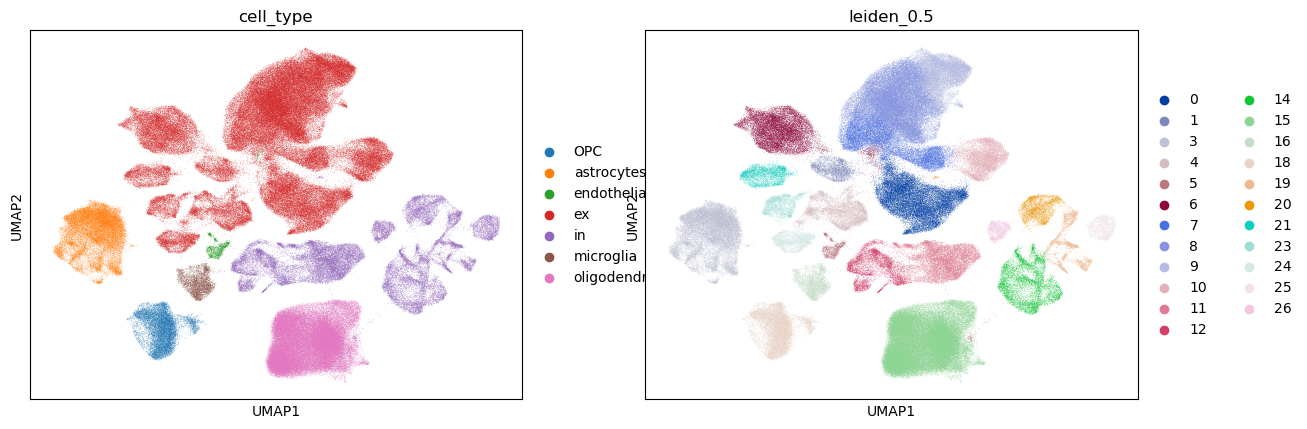

In [46]:
sc.pl.umap(adata_v, color=["cell_type","leiden_0.5"])

In [44]:
adata_v.obs

,dataset_key,dataset_id,tissue,donor_id,sample_id,sex,disease,organ_canonical,source_file,gen_sample_id,...,stage5b_mode,total_counts_mt,total_counts_rb,pct_counts_rb,scrublet_call,doublet_flag,leiden_0.1,leiden_0.5,cell_type,frac_counts_lost
AAACCCACACTTCATT-1-PFCTX001_filtered,pd_snrna_gen,pd_snrna_gen,prefrontal_cortex,NM-226,PFCTX001,F,Control,brain,PFCTX001_filtered.h5,PFCTX001,...,automatic,17,296,0.210951,singlet,True,0,0,ex,0.0
AGAAATGGTTGCTCGG-1-PFCTX001_filtered,pd_snrna_gen,pd_snrna_gen,prefrontal_cortex,NM-226,PFCTX001,F,Control,brain,PFCTX001_filtered.h5,PFCTX001,...,automatic,135,357,0.342056,singlet,False,10,6,ex,0.0
TTCACGCCATCATGAC-1-PFCTX001_filtered,pd_snrna_gen,pd_snrna_gen,prefrontal_cortex,NM-226,PFCTX001,F,Control,brain,PFCTX001_filtered.h5,PFCTX001,...,automatic,15,149,0.159596,singlet,False,4,8,ex,0.0
CTCACTGCAGGCTACC-1-PFCTX001_filtered,pd_snrna_gen,pd_snrna_gen,prefrontal_cortex,NM-226,PFCTX001,F,Control,brain,PFCTX001_filtered.h5,PFCTX001,...,automatic,296,283,0.342354,singlet,False,10,6,ex,0.0
TGCAGATTCTTCGGAA-1-PFCTX001_filtered,pd_snrna_gen,pd_snrna_gen,prefrontal_cortex,NM-226,PFCTX001,F,Control,brain,PFCTX001_filtered.h5,PFCTX001,...,automatic,15,186,0.230366,singlet,True,4,8,ex,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTCATGAGCACGGAT-1-PFCTX046_filtered,pd_snrna_gen,pd_snrna_gen,prefrontal_cortex,NM-600,PFCTX046,F,Control,brain,PFCTX046_filtered.h5,PFCTX046,...,automatic,2,0,0.000000,singlet,False,13,15,oligodendrocytes,0.0
GCGTTTCAGGTTGGTG-1-PFCTX046_filtered,pd_snrna_gen,pd_snrna_gen,prefrontal_cortex,NM-600,PFCTX046,F,Control,brain,PFCTX046_filtered.h5,PFCTX046,...,automatic,1,1,0.098328,singlet,False,13,15,oligodendrocytes,0.0
GATGACTAGGCCTTCG-1-PFCTX046_filtered,pd_snrna_gen,pd_snrna_gen,prefrontal_cortex,NM-600,PFCTX046,F,Control,brain,PFCTX046_filtered.h5,PFCTX046,...,automatic,2,1,0.098619,singlet,False,13,15,oligodendrocytes,0.0
GTGCTGGGTTTACCTT-1-PFCTX046_filtered,pd_snrna_gen,pd_snrna_gen,prefrontal_cortex,NM-600,PFCTX046,F,Control,brain,PFCTX046_filtered.h5,PFCTX046,...,automatic,0,4,0.389484,singlet,False,13,15,oligodendrocytes,0.0


In [42]:
adata_sub = adata_v[adata_v.obs.cell_type == "microglia"].copy()
adata_sub.obs.disease.value_counts()

disease
PD          2553
Control     1225
MSA          831
LRRK2_PD     444
Name: count, dtype: int64

### Notes for Ilia:

- follow the preprocessing steps in the original paper for reproducability
- dont apply the `--filter_gene_by_fraction` filter in `preprocess_scgpt.py`
- in the final dataset, check how many genes are in scGPTs vocab file (adata.var). Since we are only working with 3000 hvgs as input to scGPT you only need to check the 3000 hvgs